In [34]:
import numpy as np
import matplotlib.pyplot as plt

from imagematerials.rest_of.resource_model import ResourceModel
from imagematerials.rest_of.const import (CLASS_TO_REGION_DICT,
                                          models_output_dict,
                                          all_regions_list_class)

In [35]:
# sand
sand = ResourceModel(resource_group = 'nmm', resource = 'sand_gravel_crushed_rock', 
                       image_mat_available = True, start_year = 1970, scenario= 'SSP2_M_CP')

# collect these above defined groups in a dictionary
SAND_GROUPING_REGIONS = {
    'all_regions': [k for k in CLASS_TO_REGION_DICT.keys() if k != 'class_ 27'],
    'Canada':  ['class_ 1'],
    'China':   ['class_ 20'],
    'Average': ['class_ 5', 'class_ 12', 'class_ 13', 'class_ 14','class_ 15', 
                'class_ 16', 'class_ 17', 'class_ 18', 'class_ 19', 
                'class_ 22', 'class_ 7', 'class_ 21'],
    'Lower':    ['class_ 3', 'class_ 4', 'class_ 6', 'class_ 9', 'class_ 10', 
                 'class_ 8', 'class_ 25', 'class_ 26'],
    'Japan':    ['class_ 23'],
    'High' : ['class_ 2', 'class_ 24', 'class_ 11']
    }

sand.data_grouped_regions(regions_grouping = SAND_GROUPING_REGIONS) #list(sand_AVERAGE_REGIONS_TO_IMAGE.keys()
sand.sum_IMAGE_drivers_regions(regions_dict=None)
sand.match_MAT_data_to_regions_year(match_external_regions=False)
sand.calculate_historic_other_fraction()

# clean up negative data
sand.historic_other_fraction_consumption[sand.historic_other_fraction_consumption < 0] = np.nan
# calculate regressors
sand.calculate_regressors(sand.historic_other_fraction_consumption)


In [36]:
# Fit models 
# rmse_models = {'all_regions': 'gompertz model',
#  'Canada': 'log gauss saturate model',
#  'China': 'gompertz model',
#  'Average': 'gompertz model',
#  'Lower': 'gompertz model',
#  'Japan': 'log gauss saturate model',
#  'High': 'gompertz model'}

# bounds = {
#     'all_regions' : ([0, 0, 0], [10, 10, 10]),
#     'Canada' : ([0, 0, 0, 0], [10, 10, 10, 8]),
#     'China' : ([0, 0, 0], [8, 10, 10]),
#     'Average' : ([0, 0, 0], [10, 10, 10]),
#     'Lower' : ([0, 0, 0], [10, 10, 10]),
#     'Japan' : ([1, 0, 0, 2], [10, 10, 10, 10]),
#     'High' : ([1, 5, 0], [10, 10, 10])
# }

rmse_models = {'all_regions': 'gompertz model',
 'Canada': 'gompertz model',
 'China': 'gompertz model',
 'Average': 'gompertz model',
 'Lower': 'gompertz model',
 'Japan': 'gompertz model',
 'High': 'gompertz model'}

bounds = {
    'all_regions' : ([0, 0, 0], [10, 10, 10]),
    'Canada' : ([0, 2, 2], [10, 10, 10]),
    'China' : ([0, 0, 0], [8, 10, 10]),
    'Average' : ([0, 0, 0], [10, 10, 10]),
    'Lower' : ([0, 0, 0], [10, 10, 10]),
    'Japan' : ([0, 2, 2], [10, 10, 10]),
    'High' : ([0, 5, 0], [10, 10, 10])
}


sand.fit_models(best_rmse_models=rmse_models, bounds=bounds)

# project based on best model
sand.project_on_total(all_regions_list_class[:-1])

C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return 

In [37]:
sand.projection_per_region_total

,class_ 1,class_ 2,class_ 3,class_ 4,class_ 5,class_ 6,class_ 7,class_ 8,class_ 9,class_ 10,...,class_ 17,class_ 18,class_ 19,class_ 20,class_ 21,class_ 22,class_ 23,class_ 24,class_ 25,class_ 26
1971,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1972,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1973,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1974,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1975,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2096,4.472897e+08,2.051158e+09,5.235998e+08,3.865300e+08,7.111252e+08,8.519548e+08,1.265570e+09,5.060089e+09,2.386272e+09,2.167029e+08,...,1.593585e+09,5.416149e+09,1.791263e+08,6.870790e+09,1.639338e+09,1.123866e+09,2.856387e+08,2.312328e+08,2.935455e+09,1.551765e+09
2097,4.466743e+08,2.050268e+09,5.227046e+08,3.853626e+08,7.068978e+08,8.491212e+08,1.264899e+09,5.175552e+09,2.434693e+09,2.155990e+08,...,1.591362e+09,5.386827e+09,1.773476e+08,6.801601e+09,1.632675e+09,1.118483e+09,2.836449e+08,2.310937e+08,2.940239e+09,1.578857e+09
2098,4.460588e+08,2.049377e+09,5.217918e+08,3.841777e+08,7.026704e+08,8.462443e+08,1.264229e+09,5.285095e+09,2.480376e+09,2.144895e+08,...,1.589139e+09,5.357505e+09,1.755690e+08,6.732412e+09,1.626011e+09,1.113100e+09,2.816512e+08,2.309547e+08,2.944313e+09,1.604068e+09
2099,4.454434e+08,2.048486e+09,5.208617e+08,3.829777e+08,6.984429e+08,8.433280e+08,1.263559e+09,5.389017e+09,2.523436e+09,2.133752e+08,...,1.586916e+09,5.328177e+09,1.737904e+08,6.663222e+09,1.619348e+09,1.107717e+09,2.796574e+08,2.308156e+08,2.947761e+09,1.627515e+09


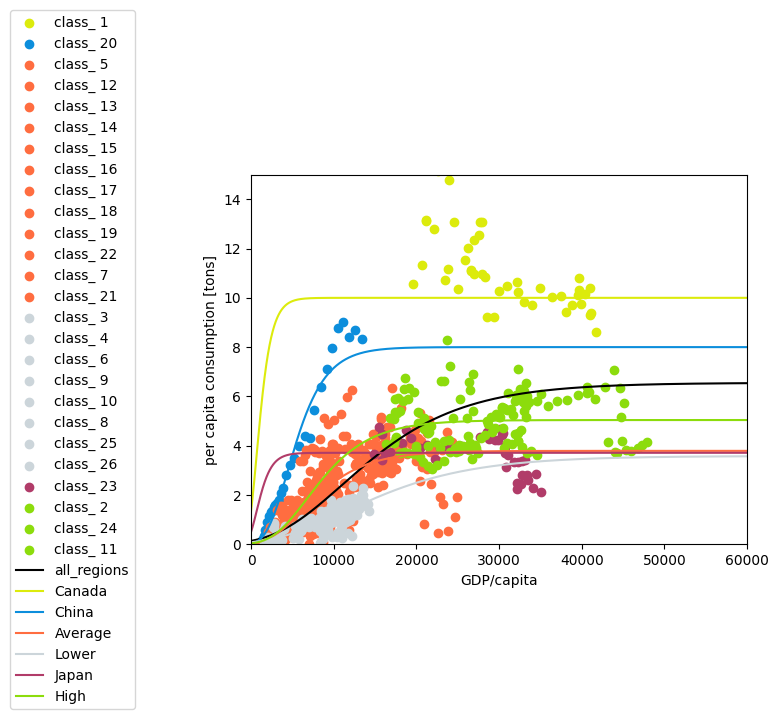

In [38]:
# Plot 
color_dict = {
    'Canada': "#dceb0c",  # Color for Canada
    'China': "#0c8edc",   # Color for China
    'Average': "#ff6d40", # Color for Average
    'Lower': "#ccd5da",   # Color for Lower
    'Japan': "#b13c69",   # Color for Japan
    'High': "#8cdc0c",     # Color for High
    'all_regions': "#000000"  # Color for all regions
}

X_pred = np.arange(1, 60000).reshape(-1, 1).astype(float)

fig, ax = plt.subplots()             # Create a figure containing a single Axes.

for region, classes in SAND_GROUPING_REGIONS.items():
    if region == 'all_regions':
        continue
    for class_names in classes:
            ax.scatter(sand.gdp_pc[class_names], 
                       sand.cons_capita[class_names], 
                       label = class_names,
                       color = color_dict.get(region))
            
for grouping in SAND_GROUPING_REGIONS.keys():
    model = sand.model_groups[grouping][models_output_dict[sand.best_rmse_models[grouping]]]
    ax.plot(model.predict(X_pred),
            label = grouping,
            color = color_dict[grouping])

# set x axis limits
ax.set_xlim(0, 60000)
ax.set_ylim(0, 15)

ax.set_ylabel("per capita consumption [tons]")
ax.set_xlabel("GDP/capita")
plt.legend(loc = 'center left', bbox_to_anchor=(-0.5, 0.5))

In [39]:
sand.smooth_out_interpolation_all(10, 2017)

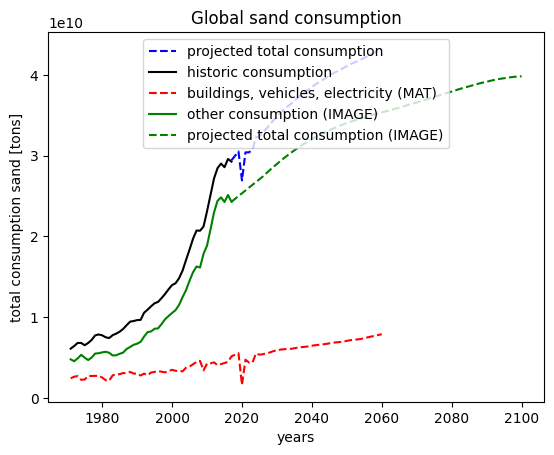

In [40]:
fig, ax = plt.subplots()             # Create a figure containing a single Axes.

ax.plot(sand.projection_per_region_total.sum(axis = 1) + sand.image_mat_data.sum(axis = 1).loc[2017:], 
        linestyle = '--', color = 'blue', label = 'projected total consumption')
ax.plot(sand.historic_consumption_data.sum(axis = 1),
        linestyle = '-', color = 'black', label = 'historic consumption')  

ax.plot(sand.image_mat_data.sum(axis = 1).loc[1971:],
        linestyle = '--', color = 'red', label = 'buildings, vehicles, electricity (MAT)')
ax.plot(sand.historic_other_fraction_consumption.sum(axis = 1),
        linestyle = '-', color = 'green', label = 'other consumption (IMAGE)')

ax.plot(sand.projection_per_region_total.loc[2017: ].sum(axis = 1),
        linestyle = '--', color = 'green', label = 'projected total consumption (IMAGE)')

ax.set_ylabel("total consumption sand [tons]")
ax.set_xlabel("years") 
ax.title.set_text("Global sand consumption")
ax.legend(loc = 'upper center')